In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression , Lasso , Ridge 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from xgboost import XGBRegressor 
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import r2_score , mean_squared_error
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
from sklearn.model_selection import KFold
from pathlib import Path
import os

In [70]:

IN_KAGGLE = os.path.exists('/kaggle/input')

if IN_KAGGLE:
    # Kaggle غيّر اسم الفولدر ده للأساسي في المسابقة على 
    DATA_DIR = Path('/kaggle/input/house-prices-advanced-regression-techniques')
else:
    DATA_DIR = Path.cwd().parent / "datasets" / "processed"

train_new_data = pd.read_csv(DATA_DIR / 'train_processed.csv')


print(f'train dataset shape = {train_new_data.shape}')

train dataset shape = (1458, 268)


In [71]:
train_new_data = train_new_data.drop(
    columns=['Id', 'MoSold', 'YrSold'],
    errors='ignore'
)

print(f'train dataset shape = {train_new_data.shape}')

train dataset shape = (1458, 265)


In [72]:
X_train = train_new_data.drop('SalePrice', axis = 1)

import re
X_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X_train.columns]

y_train = train_new_data['SalePrice']

X_train.shape , y_train.shape

((1458, 264), (1458,))

In [73]:
models = {

'Linear_Regression' : LinearRegression() , 'lasso' : Lasso() ,
'ridge' : Ridge() , 'Decision_Tree_Regressor' : DecisionTreeRegressor(random_state=42), 
'Random_Forest_Regressor' : RandomForestRegressor(random_state=42) , 
'Gradient_Boosting_Regressor' : GradientBoostingRegressor(random_state=42),
'XGB_Regressor' : XGBRegressor(random_state=42 , objective='reg:squarederror') ,
'LGBM_Regressor' : LGBMRegressor(random_state=42),
'Cat_Boost_Regressor' : CatBoostRegressor(verbose=0 , random_state=42 )

          }

In [74]:
models_scores = {}
scores = {'r2_score':'r2' , 'RMSE' : 'neg_root_mean_squared_error'}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name_model , model in models.items():

    cv_results = cross_validate(
        model , X_train , y_train ,cv= cv , scoring=scores , return_train_score=True )


    models_scores[name_model] = {

        'CV_Train_R2_Score' : cv_results['train_r2_score'].mean() ,
        'CV_Test_R2_Score' : cv_results['test_r2_score'].mean(),
        'CV_Train_RMSE' : - cv_results['train_RMSE'].mean() ,
        'CV_Test_RMSE' : - cv_results['test_RMSE'].mean()

                                }
    
    

models_scores_df = pd.DataFrame(
        models_scores).T.sort_values(by='CV_Test_RMSE', ascending=False
                                )


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000895 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3819
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 175
[LightGBM] [Info] Start training from score 11.503431
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3818
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 176
[LightGBM] [Info] Start training from score 11.512864
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001354 seconds.
You can

In [75]:
models_scores_df 

,CV_Train_R2_Score,CV_Test_R2_Score,CV_Train_RMSE,CV_Test_RMSE
Decision_Tree_Regressor,1.000000,0.442534,-0.000000,0.398816
lasso,0.631331,0.619626,0.324468,0.329127
Linear_Regression,0.808519,0.623840,0.233796,0.326220
ridge,0.801729,0.676999,0.237909,0.302506
XGB_Regressor,0.999694,0.718845,0.009264,0.282956
LGBM_Regressor,0.981355,0.744853,0.072946,0.269510
Random_Forest_Regressor,0.962148,0.746163,0.103962,0.268778
Gradient_Boosting_Regressor,0.896499,0.750152,0.171898,0.266713
Cat_Boost_Regressor,0.980238,0.760778,0.075080,0.260727


##### CV Test RMSE Comparison Across Models

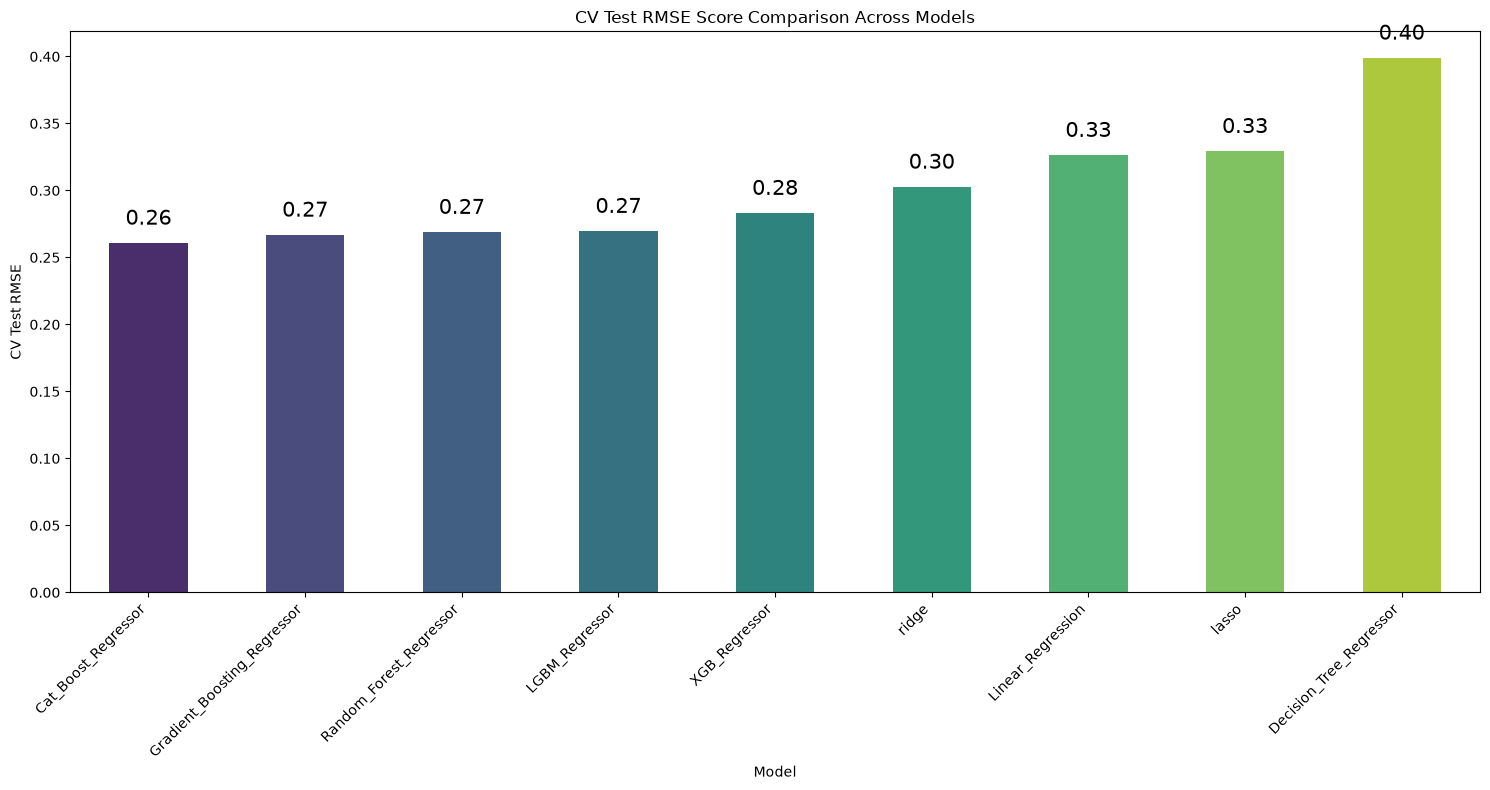

In [76]:
models_scores_sorted_train_score = models_scores_df.sort_values(
    by='CV_Test_RMSE' )


fig , ax = plt.subplots(figsize = (15 , 8))
sns.barplot(x = models_scores_sorted_train_score.index ,
 y = models_scores_sorted_train_score['CV_Test_RMSE'], 
palette='viridis',hue = models_scores_sorted_train_score.index , legend=False , width = 0.5 )


for i , v in enumerate(models_scores_sorted_train_score['CV_Test_RMSE']):
    ax.text(i , v + 0.01 , f'{v:.2f}', ha='center', va='bottom', fontsize=15 )


plt.xlabel('Model')
plt.ylabel('CV Test RMSE')
plt.title('CV Test RMSE Score Comparison Across Models')
plt.xticks(rotation = 45 , ha='right')
plt.tight_layout()
plt.show()

##### CV Test R2 Score Comparison Across Models

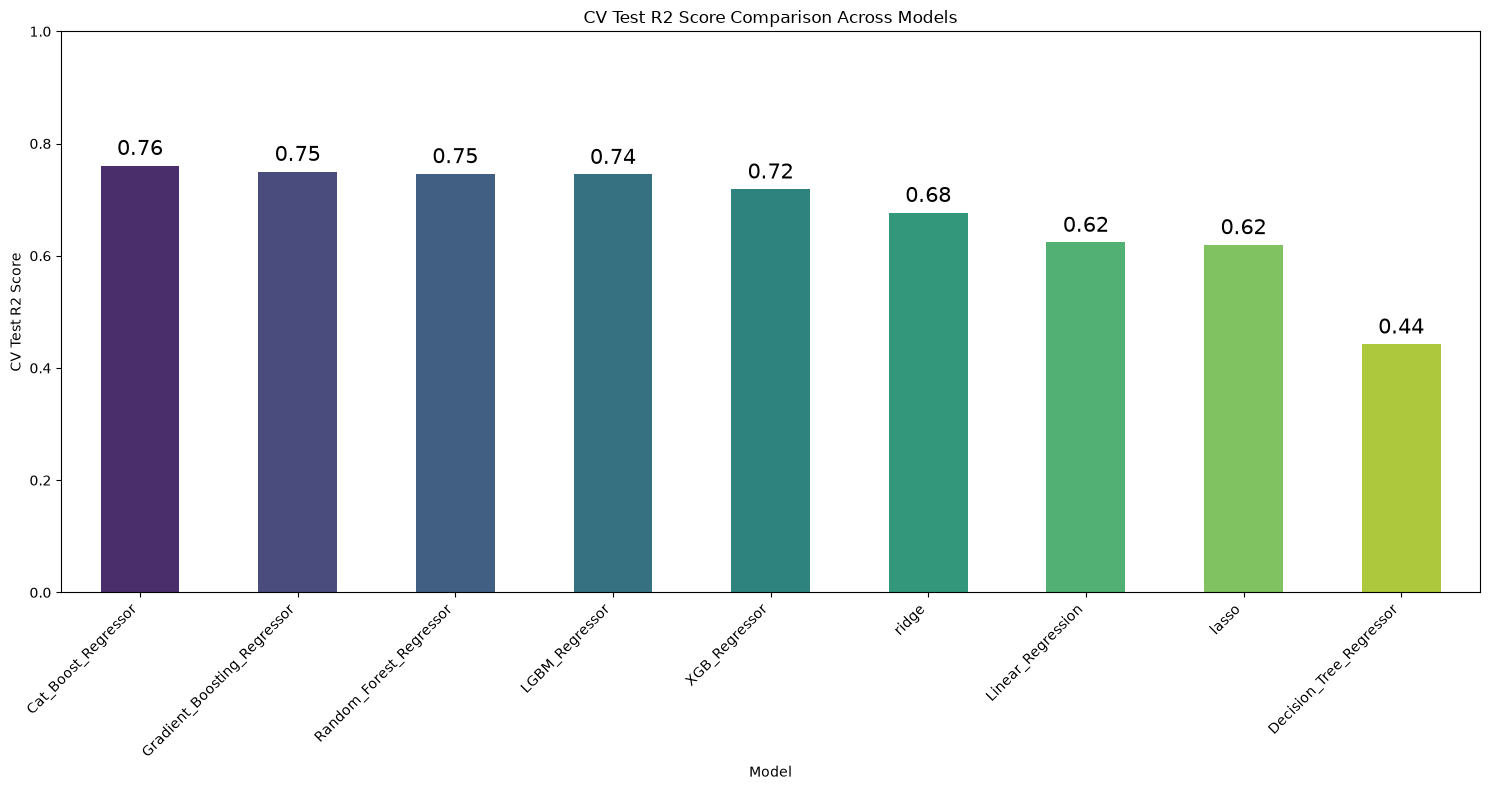

In [77]:
models_scores_sorted_train_score = models_scores_df.sort_values(
    by='CV_Test_R2_Score' , ascending=False)


fig , ax = plt.subplots(figsize = (15 , 8))
sns.barplot(x = models_scores_sorted_train_score.index ,
 y = models_scores_sorted_train_score['CV_Test_R2_Score'], 
palette='viridis',hue = models_scores_sorted_train_score.index , legend=False , width = 0.5 )


for i , v in enumerate(models_scores_sorted_train_score['CV_Test_R2_Score']):
    ax.text(i , v + 0.01 , f'{v:.2f}', ha='center', va='bottom', fontsize=15 )


plt.xlabel('Model')
plt.ylabel('CV Test R2 Score')
plt.title('CV Test R2 Score Comparison Across Models')
plt.xticks(rotation = 45 , ha='right')
plt.ylim(0 , 1)
plt.tight_layout()
plt.show()


##### CV Train R2 Score Comparison Across Models

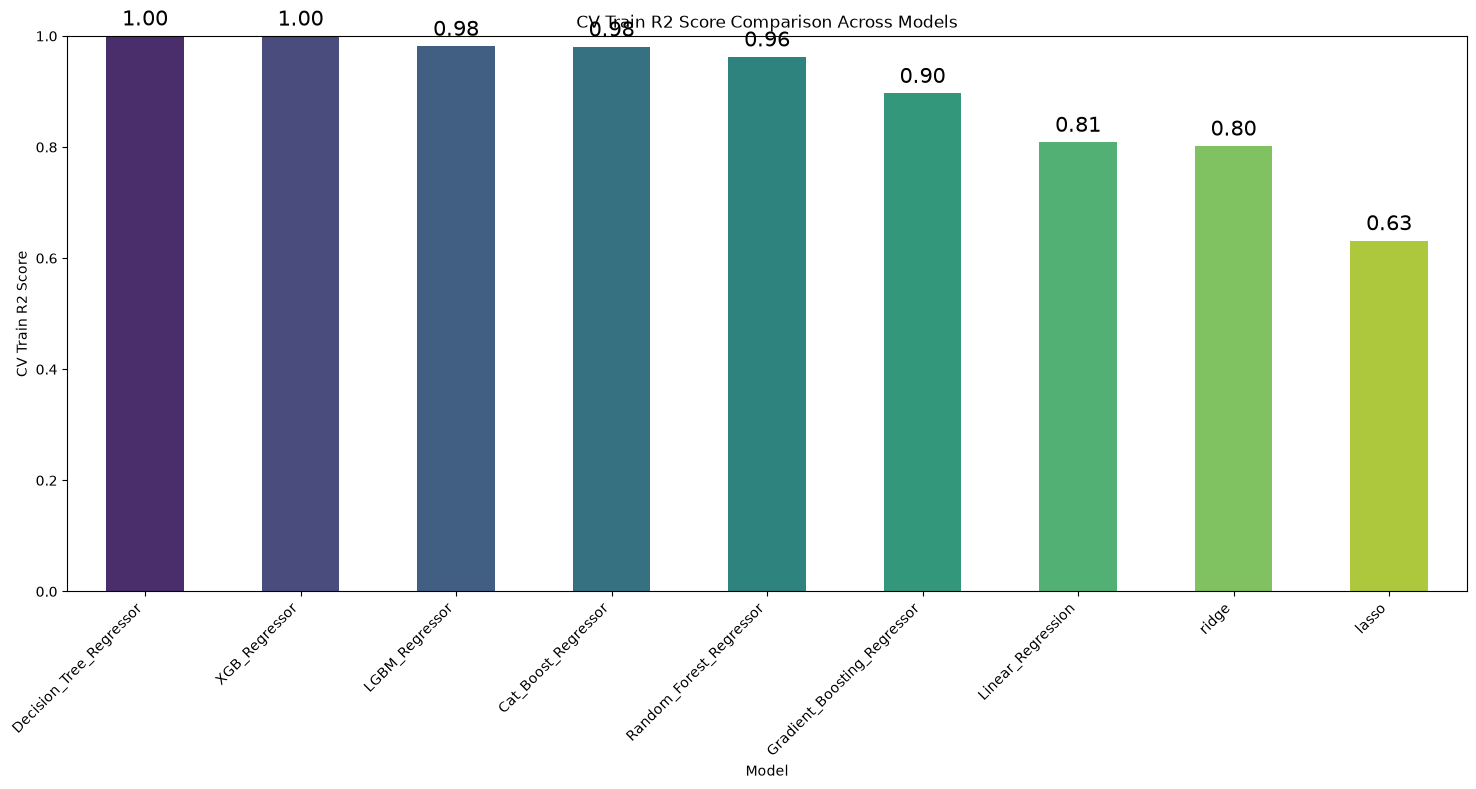

In [78]:
models_scores_sorted_train_score = models_scores_df.sort_values(
    by='CV_Train_R2_Score' , ascending=False)


fig , ax = plt.subplots(figsize = (15 , 8))
sns.barplot(x = models_scores_sorted_train_score.index ,
 y = models_scores_sorted_train_score['CV_Train_R2_Score'], 
palette='viridis',hue = models_scores_sorted_train_score.index , legend=False , width = 0.5 )


for i , v in enumerate(models_scores_sorted_train_score['CV_Train_R2_Score']):
    ax.text(i , v + 0.01 , f'{v:.2f}', ha='center', va='bottom', fontsize=15 )


plt.xlabel('Model')
plt.ylabel('CV Train R2 Score')
plt.title('CV Train R2 Score Comparison Across Models')
plt.xticks(rotation = 45 , ha='right')
plt.ylim(0 , 1)
plt.tight_layout()
plt.show()

##### we will try these models :
- Cat_Boost_Regressor , Gradient_Boosting_Regressor, XGB_Regressor 
- LGBM_Regressor , Random_Forest_Regressor

In [79]:
CatBoostRegressor_model = CatBoostRegressor(verbose=0)
GradientBoostingRegressor_model = GradientBoostingRegressor()
XGBRegressor_model = XGBRegressor()
LGBMRegressor_model = LGBMRegressor()
RandomForestRegressor_model = RandomForestRegressor()


best_models = { 

'Cat_Boost_Regressor':CatBoostRegressor_model , 
'Gradient_Boosting_Regressor' : GradientBoostingRegressor_model ,
'XGB_Regressor' : XGBRegressor_model ,  'LGBM_Regressor' : LGBMRegressor_model ,
'Random_Forest_Regressor' : RandomForestRegressor_model

              }

In [80]:

best_params = {
     'Cat_Boost_Regressor' : {'iterations' : [ 500 , 1000 , 1500 ],
                              'learning_rate' : [ 0.01 , 0.03 , 0.05 , 0.1],
                              'depth' : [4 , 6 , 8 , 10 ],
                              'l2_leaf_reg' : [1 , 3 , 5 , 7 , 9 ],
                              'bootstrap_type' : ['Bernoulli'],
                              'subsample' : [ 0.66 , 0.8 ]
                              } ,

    'Gradient_Boosting_Regressor' : {'n_estimators' : [100 , 200 , 500 ],
                                     'learning_rate' : [0.03 , 0.05 , 0.1],
                                     'max_depth' : [2 , 3 , 4] ,
                                     'subsample' : [0.8 , 1],
                                     'min_samples_split' : [ 2 , 5 ],
                                     'min_samples_leaf' : [1 , 2]
                                     },

    'XGB_Regressor' : { 'n_estimators' : [100 , 300 , 500 , 800 , 1000 ],
                        'learning_rate' : [ 0.01 ,0.03 , 0.05 , 0.1],
                        'max_depth' : [3 , 4 , 5 , 6] ,
                        'subsample' : [ 0.7 ,0.8 , 0.9 , 1],
                        'colsample_bytree' : [0.7 ,0.8 , 0.9 , 1],
                        'min_child_weight' : [1 , 3 , 5 ],
                        'gamma' : [0 , 0.01 , 0.3],
                        'reg_alpha' : [0 , 0.01 , 0.1],
                        'reg_lambda' : [1 , 3 , 5]
                       },

    'LGBM_Regressor' : { 'n_estimators' : [100 , 300 , 500 , 1000 ],
                        'learning_rate' : [0.01 , 0.03 , 0.05 , 0.1],
                        'max_depth' : [ 1 , 3 , 4 , 6 , 7 ] ,
                        'num_leaves' : [31 , 50 , 70] ,
                        'subsample' : [0.8 , 1],
                        'colsample_bytree' : [0.8 , 1],
                        'min_child_samples' : [10 , 20 , 30 ],
                       },

    'Random_Forest_Regressor' : {'n_estimators' : [100 , 500 , 1000 ],
                                 'max_depth' : [10 , 20 ,None],
                                 'min_samples_split' : [ 2 , 5 ],
                                 'min_samples_leaf' : [1 , 2] ,
                                 'max_features' : ['sqrt', 'log2']
                                 }
           }

In [66]:
fitted_models = {}

for name_model , model in best_models.items():

    Random_GridSearchCV_model = RandomizedSearchCV ( 
        model , best_params[name_model], n_iter=150 , n_jobs= -1 ,
        cv = cv , scoring='neg_root_mean_squared_error' , return_train_score=True , random_state=42
                                             )
    
    Random_GridSearchCV_model.fit(X_train , y_train)

    fitted_models[name_model] = Random_GridSearchCV_model

    print(f'\n{name_model} - Best RMSE = {Random_GridSearchCV_model.best_score_}')
    print(f'{name_model} - Best params = {Random_GridSearchCV_model.best_params_}\n{"-" *50}\n')



Cat_Boost_Regressor - Best RMSE = -0.25717674263251317
Cat_Boost_Regressor - Best params = {'subsample': 0.66, 'learning_rate': 0.01, 'l2_leaf_reg': 1, 'iterations': 1500, 'depth': 8, 'bootstrap_type': 'Bernoulli'}
--------------------------------------------------


Gradient_Boosting_Regressor - Best RMSE = -0.2616782967596348
Gradient_Boosting_Regressor - Best params = {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 4, 'learning_rate': 0.03}
--------------------------------------------------


XGB_Regressor - Best RMSE = -0.25950261652469636
XGB_Regressor - Best params = {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}
--------------------------------------------------

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002275 seconds.
You can set `force_row_wise=true` to 

c:\Users\B-UNIT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 72 is smaller than n_iter=150. Running 72 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Random_Forest_Regressor - Best RMSE = -0.26129977956412975
Random_Forest_Regressor - Best params = {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
--------------------------------------------------



In [67]:

best_CatBoostRegressor_model = fitted_models['Cat_Boost_Regressor'].best_estimator_

best_GradientBoostingRegressor_model = fitted_models['Gradient_Boosting_Regressor'].best_estimator_

best_XGBRegressor_model = fitted_models['XGB_Regressor'].best_estimator_

best_LGBMRegressor_model = fitted_models['LGBM_Regressor'].best_estimator_

best_RandomForestRegressor_model = fitted_models['Random_Forest_Regressor'].best_estimator_


In [68]:
import joblib
from pathlib import Path

# فولدر الموديلات بره notebooks/ (زي هيكل مشروعك في الصورة)
MODELS_DIR = Path.cwd().parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

trained_models = {
    'Cat_Boost_Regressor': best_CatBoostRegressor_model,
    'Gradient_Boosting_Regressor': best_GradientBoostingRegressor_model,
    'XGB_Regressor': best_XGBRegressor_model,
    'LGBM_Regressor': best_LGBMRegressor_model,
    'Random_Forest_Regressor': best_RandomForestRegressor_model
}

for name, model in trained_models.items():
    joblib.dump(model, MODELS_DIR / f'{name}_model.pkl')
    print(f'✅ Saved: {name}_model.pkl')

✅ Saved: Cat_Boost_Regressor_model.pkl
✅ Saved: Gradient_Boosting_Regressor_model.pkl
✅ Saved: XGB_Regressor_model.pkl
✅ Saved: LGBM_Regressor_model.pkl
✅ Saved: Random_Forest_Regressor_model.pkl
